# Transfer Learning Using AlexNet, VGG16, ResNet50 and EfficientNetB0

**Assignment:** Implement transfer learning using pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0 models for image classification and compare their performance.

**Dataset:** CIFAR-10  
**Task:** 10-class image classification  
**Framework:** PyTorch + torchvision  
**Pre-trained weights:** ImageNet  
**Approach:** Freeze the pre-trained feature extractor and train a new classification head for CIFAR-10.

> **Note:** AlexNet is available through `torchvision.models`, while VGG16, ResNet50 and EfficientNetB0 are also loaded with their official ImageNet weights.

In [ ]:
# Install/upgrade required libraries
!pip install -q --upgrade torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 853.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/

In [ ]:
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.14.0+cu130
Torchvision version: 0.29.0+cu130
Device: cpu


## 1. Load the CIFAR-10 Dataset

CIFAR-10 contains 60,000 color images belonging to 10 classes. Since ImageNet-pretrained models expect larger images, CIFAR-10 images are resized to **224 × 224** and normalized using ImageNet mean and standard deviation.

In [ ]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset_full = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Full training samples:", len(train_dataset_full))
print("Full testing samples:", len(test_dataset_full))
print("Number of classes:", len(classes))

100%|██████████| 170M/170M [37:20<00:00, 76.1kB/s]


Full training samples: 50000
Full testing samples: 10000
Number of classes: 10


## 2. Create a Practical Subset

Training four large pre-trained networks on the complete CIFAR-10 dataset can take considerable time on a Colab runtime. For a practical assignment comparison, this notebook uses a reproducible subset.

- Training subset: **10,000 images**
- Testing subset: **2,000 images**

You can set `USE_SUBSET = False` to use the complete dataset.

In [ ]:
USE_SUBSET = True

TRAIN_SAMPLES = 10000
TEST_SAMPLES = 2000

if USE_SUBSET:
    train_indices = np.random.RandomState(SEED).choice(
        len(train_dataset_full),
        TRAIN_SAMPLES,
        replace=False
    )
    test_indices = np.random.RandomState(SEED).choice(
        len(test_dataset_full),
        TEST_SAMPLES,
        replace=False
    )

    train_dataset = Subset(train_dataset_full, train_indices)
    test_dataset = Subset(test_dataset_full, test_indices)
else:
    train_dataset = train_dataset_full
    test_dataset = test_dataset_full

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training samples used:", len(train_dataset))
print("Testing samples used:", len(test_dataset))

Training samples used: 10000
Testing samples used: 2000


## 3. Visualize Sample Images

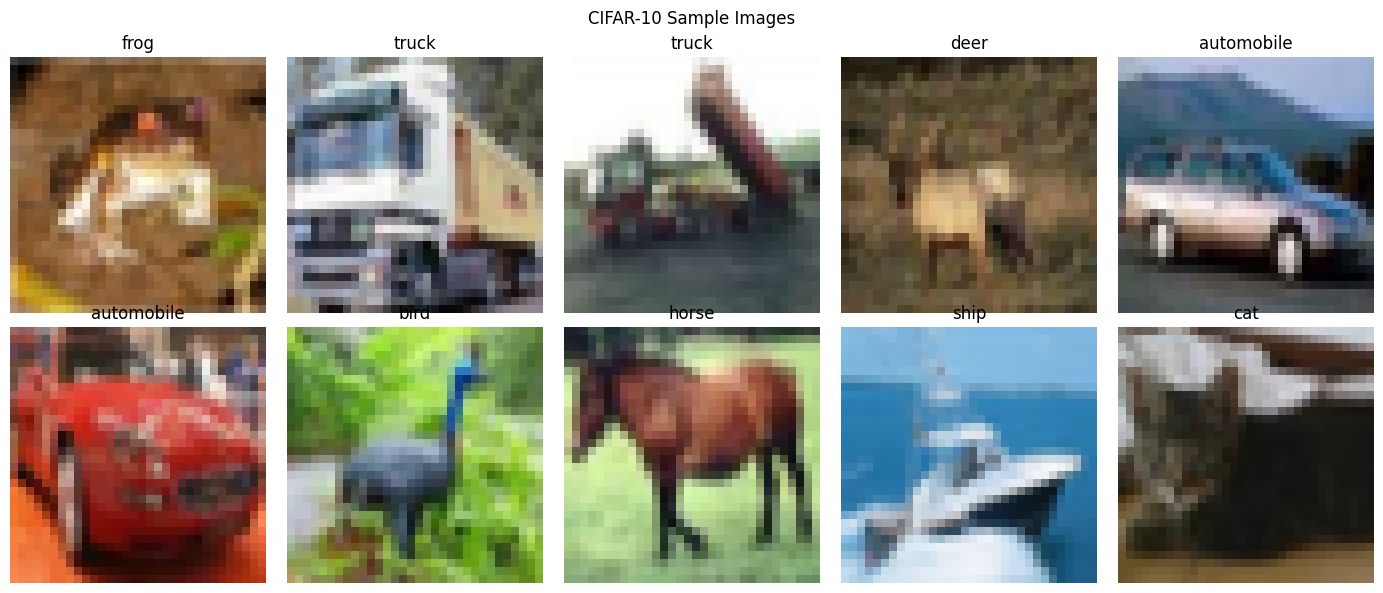

In [ ]:
# Load an unnormalized dataset only for clean visualization
visual_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, idx in zip(axes.flat, range(10)):
    image, label = visual_dataset[idx]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[label])
    ax.axis("off")

plt.suptitle("CIFAR-10 Sample Images")
plt.tight_layout()
plt.show()

## 4. Load Pre-trained Models

All four models use **ImageNet-pretrained weights**. The original 1,000-class classification layer is replaced with a new 10-class CIFAR-10 classification layer.

Transfer learning workflow:

`ImageNet Pre-trained Model → Freeze Feature Extractor → Replace Classifier → Train on CIFAR-10`

In [ ]:
def build_alexnet(num_classes=10):
    weights = models.AlexNet_Weights.DEFAULT
    model = models.alexnet(weights=weights)

    # Freeze all pre-trained parameters
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier with CIFAR-10 classifier
    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features,
        num_classes
    )

    return model


def build_vgg16(num_classes=10):
    weights = models.VGG16_Weights.DEFAULT
    model = models.vgg16(weights=weights)

    for param in model.features.parameters():
        param.requires_grad = False

    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features,
        num_classes
    )

    return model


def build_resnet50(num_classes=10):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model


def build_efficientnetb0(num_classes=10):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    for param in model.features.parameters():
        param.requires_grad = False

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )

    return model


model_builders = {
    "AlexNet": build_alexnet,
    "VGG16": build_vgg16,
    "ResNet50": build_resnet50,
    "EfficientNetB0": build_efficientnetb0
}

print("Model builders created successfully.")

Model builders created successfully.


## 5. Check Trainable Parameters

In [ ]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

parameter_rows = []

for name, builder in model_builders.items():
    model = builder()
    total, trainable = count_parameters(model)

    parameter_rows.append({
        "Model": name,
        "Total Parameters": total,
        "Trainable Parameters": trainable
    })

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

parameter_df = pd.DataFrame(parameter_rows)
display(parameter_df)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 105MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.0MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.2MB/s]


,Model,Total Parameters,Trainable Parameters
0,AlexNet,57044810,54575114
1,VGG16,134301514,119586826
2,ResNet50,23528522,20490
3,EfficientNetB0,4020358,12810


## 6. Define Training and Evaluation Functions

In [ ]:
def train_model(model, train_loader, criterion, optimizer, epochs=3):
    model = model.to(device)

    history = {
        "train_loss": [],
        "train_accuracy": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        history["train_loss"].append(epoch_loss)
        history["train_accuracy"].append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_accuracy:.4f}"
        )

    training_time = time.time() - start_time

    return model, history, training_time


def evaluate_model(model, test_loader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "True Labels": all_labels,
        "Predictions": all_predictions
    }

## 7. Train and Evaluate All Four Models

For a fair comparison, the same:
- dataset subset
- image preprocessing
- batch size
- optimizer
- learning rate
- number of epochs

are used for each model.

Only the architecture changes.

In [ ]:
EPOCHS = 3
LEARNING_RATE = 0.001

all_results = []
all_histories = {}
all_predictions = {}

for name, builder in model_builders.items():
    print("\n" + "=" * 70)
    print(f"TRAINING {name}")
    print("=" * 70)

    model = builder()

    criterion = nn.CrossEntropyLoss()

    trainable_params = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    optimizer = optim.Adam(
        trainable_params,
        lr=LEARNING_RATE
    )

    model, history, training_time = train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        epochs=EPOCHS
    )

    evaluation = evaluate_model(
        model,
        test_loader
    )

    total_params, trainable_params_count = count_parameters(model)

    all_results.append({
        "Model": name,
        "Accuracy": evaluation["Accuracy"],
        "Precision": evaluation["Precision"],
        "Recall": evaluation["Recall"],
        "F1 Score": evaluation["F1 Score"],
        "Training Time (sec)": training_time,
        "Total Parameters": total_params,
        "Trainable Parameters": trainable_params_count
    })

    all_histories[name] = history
    all_predictions[name] = evaluation

    print(f"Test Accuracy: {evaluation['Accuracy']:.4f}")
    print(f"Test Precision: {evaluation['Precision']:.4f}")
    print(f"Test Recall: {evaluation['Recall']:.4f}")
    print(f"Test F1 Score: {evaluation['F1 Score']:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results)
display(results_df.round(4))


TRAINING AlexNet
Epoch [1/3] | Loss: 0.9839 | Accuracy: 0.6604
Epoch [2/3] | Loss: 0.6650 | Accuracy: 0.7658
Epoch [3/3] | Loss: 0.5785 | Accuracy: 0.8021
Test Accuracy: 0.7570
Test Precision: 0.7850
Test Recall: 0.7570
Test F1 Score: 0.7579
Training Time: 1693.06 seconds

TRAINING VGG16


## 8. Compare Accuracy, Precision, Recall and F1 Score

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Transfer Learning Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()

## 9. Compare Training Time

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["Training Time (sec)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.grid(axis="y")
plt.show()

## 10. Compare Total and Trainable Parameters

In [ ]:
parameter_plot_df = results_df.set_index("Model")[
    ["Total Parameters", "Trainable Parameters"]
]

ax = parameter_plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Parameter Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## 11. Plot Training Accuracy

In [ ]:
plt.figure(figsize=(12, 6))

for name, history in all_histories.items():
    plt.plot(
        range(1, len(history["train_accuracy"]) + 1),
        history["train_accuracy"],
        marker="o",
        label=name
    )

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 12. Confusion Matrices

In [ ]:
for name, evaluation in all_predictions.items():
    cm = confusion_matrix(
        evaluation["True Labels"],
        evaluation["Predictions"]
    )

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(range(10), classes, rotation=45, ha="right")
    plt.yticks(range(10), classes)

    for i in range(10):
        for j in range(10):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=8
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

## 13. Classification Reports

In [ ]:
for name, evaluation in all_predictions.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            evaluation["True Labels"],
            evaluation["Predictions"],
            target_names=classes,
            zero_division=0
        )
    )

## 14. Final Comparison Table

The table below summarizes the major performance measures. Because deep-learning training is stochastic, exact numerical values can vary slightly between runs.

In [ ]:
final_table = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)",
        "Total Parameters",
        "Trainable Parameters"
    ]
].copy()

display(final_table.round(4))